# Regression in Python

***
This is a very quick run-through of some basic statistical concepts, adapted from [Lab 4 in Harvard's CS109](https://github.com/cs109/2015lab4) course. Please feel free to try the original lab if you're feeling ambitious :-) The CS109 git repository also has the solutions if you're stuck.

* Linear Regression Models
* Prediction using linear regression

Linear regression is used to model and predict continuous outcomes with normal random errors. There are nearly an infinite number of different types of regression models and each regression model is typically defined by the distribution of the prediction errors (called "residuals") of the type of data. Logistic regression is used to model binary outcomes whereas Poisson regression is used to predict counts. In this exercise, we'll see some examples of linear regression as well as Train-test splits.

The packages we'll cover are: `statsmodels`, `seaborn`, and `scikit-learn`. While we don't explicitly teach `statsmodels` and `seaborn` in the Springboard workshop, those are great libraries to know.
***

<img width=600 height=300 src="https://imgs.xkcd.com/comics/sustainable.png"/>
***

In [1]:
# special IPython command to prepare the notebook for matplotlib and other libraries
%matplotlib inline 

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn

import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


***
# Part 1: Introduction to Linear Regression
### Purpose of linear regression
***
<div class="span5 alert alert-info">

<p> Given a dataset containing predictor variables $X$ and outcome/response variable $Y$, linear regression can be used to: </p>
<ul>
  <li> Build a <b>predictive model</b> to predict future values of $\hat{Y}$, using new data $X^*$ where $Y$ is unknown.</li>
  <li> Model the <b>strength of the relationship</b> between each independent variable $X_i$ and $Y$</li>
    <ul>
      <li> Many times, only a subset of independent variables $X_i$ will have a linear relationship with $Y$</li>
      <li> Need to figure out which $X_i$ contributes most information to predict $Y$ </li>
    </ul>
   <li>It is in many cases, the first pass prediction algorithm for continuous outcomes. </li>
</ul>
</div>

### A Brief Mathematical Recap
***

[Linear Regression](http://en.wikipedia.org/wiki/Linear_regression) is a method to model the relationship between a set of independent variables $X$ (also knowns as explanatory variables, features, predictors) and a dependent variable $Y$.  This method assumes the relationship between each predictor $X$ is **linearly** related to the dependent variable $Y$. The most basic linear regression model contains one independent variable $X$, we'll call this the simple model. 

$$ Y = \beta_0 + \beta_1 X + \epsilon$$

where $\epsilon$ is considered as an unobservable random variable that adds noise to the linear relationship. In linear regression, $\epsilon$ is assumed to be normally distributed with a mean of 0. In other words, what this means is that on average, if we know $Y$, a roughly equal number of predictions $\hat{Y}$ will be above $Y$ and others will be below $Y$. That is, on average, the error is zero. The residuals, $\epsilon$ are also assumed to be "i.i.d.": independently and identically distributed. Independence means that the residuals are not correlated -- the residual from one prediction has no effect on the residual from another prediction. Correlated errors are common in time series analysis and spatial analyses.

* $\beta_0$ is the intercept of the linear model and represents the average of $Y$ when all independent variables $X$ are set to 0.

* $\beta_1$ is the slope of the line associated with the regression model and represents the average effect of a one-unit increase in $X$ on $Y$.

* Back to the simple model. The model in linear regression is the *conditional mean* of $Y$ given the values in $X$ is expressed a linear function.  

$$ y = f(x) = E(Y | X = x)$$ 

![conditional mean](images/conditionalmean.png)
*Image from http://www.learner.org/courses/againstallodds/about/glossary.html. Note this image uses $\alpha$ and $\beta$ instead of $\beta_0$ and $\beta_1$.*

* The goal is to estimate the coefficients (e.g. $\beta_0$ and $\beta_1$). We represent the estimates of the coefficients with a "hat" on top of the letter.  

$$ \hat{\beta}_0, \hat{\beta}_1 $$

* Once we estimate the coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$, we can use these to predict new values of $Y$ given new data $X$.

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1$$

* Multiple linear regression is when you have more than one independent variable and the estimation involves matrices
    * $X_1$, $X_2$, $X_3$, $\ldots$


* How do you estimate the coefficients? 
    * There are many ways to fit a linear regression model
    * The method called **least squares** is the most common methods
    * We will discuss least squares

$$ Y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon$$ 
    
### Estimating $\hat\beta$: Least squares
***
[Least squares](http://en.wikipedia.org/wiki/Least_squares) is a method that can estimate the coefficients of a linear model by minimizing the squared residuals: 

$$ \mathscr{L} = \sum_{i=1}^N \epsilon_i^2 = \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2  = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

where $N$ is the number of observations and $\epsilon$ represents a residual or error, ACTUAL - PREDICTED.  

#### Estimating the intercept $\hat{\beta_0}$ for the simple linear model

We want to minimize the squared residuals and solve for $\hat{\beta_0}$ so we take the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta_0}$ 

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_0}} &= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= -2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \hspace{25mm} \mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) \\
&= -2 \left[ \left( \sum_{i=1}^N y_i \right) - N \hat{\beta_0} - \hat{\beta}_1 \left( \sum_{i=1}^N x_i
\right) \right] \\
& 2 \left[ N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i \right] = 0 \hspace{20mm} \mbox{(Set equal to 0 and solve for $\hat{\beta}_0$)} \\
& N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i = 0 \\
& N \hat{\beta}_0 = \sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i}{N} \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i}{N} - \hat{\beta}_1 \frac{\sum_{i=1}^N x_i}{N} \\
& \boxed{\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}}
\end{align}
$

Using this new information, we can compute the estimate for $\hat{\beta}_1$ by taking the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta}_1$.

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_1}} &= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= 2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \left( -x_i \right) \hspace{25mm}\mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N x_i \left( y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i \right) \\
&= -2 \sum_{i=1}^N x_i (y_i - \hat{\beta}_0 x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N x_i (y_i - \left( \bar{y} - \hat{\beta}_1 \bar{x} \right) x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N (x_i y_i - \bar{y}x_i + \hat{\beta}_1\bar{x}x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \left[ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i + \hat{\beta}_1\bar{x}\sum_{i=1}^N x_i - \hat{\beta}_1 \sum_{i=1}^N x_i^2 \right] \\
&= -2 \left[ \hat{\beta}_1 \left\{ \bar{x} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i^2 \right\} + \left\{ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i \right\}\right] \\
& 2 \left[ \hat{\beta}_1 \left\{ \sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i \right\} + \left\{ \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right\} \right] = 0 \\
& \hat{\beta}_1 = \frac{-\left( \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right)}{\sum_{i=1}^N x_i^2 - \bar{x}\sum_{i=1}^N x_i} \\
&= \frac{\sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i}{\sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i} \\
& \boxed{\hat{\beta}_1 = \frac{\sum_{i=1}^N x_i y_i - \bar{x}\bar{y}n}{\sum_{i=1}^N x_i^2 - n \bar{x}^2}}
\end{align}
$

The solution can be written in compact matrix notation as

$$\hat\beta =  (X^T X)^{-1}X^T Y$$ 

We wanted to show you this in case you remember linear algebra, in order for this solution to exist we need $X^T X$ to be invertible. Of course this requires a few extra assumptions, $X$ must be full rank so that $X^T X$ is invertible, etc. Basically, $X^T X$ is full rank if all rows and columns are linearly independent. This has a loose relationship to variables and observations being independent respective. **This is important for us because this means that having redundant features in our regression models will lead to poorly fitting (and unstable) models.** We'll see an implementation of this in the extra linear regression example.

***
# Part 2: Exploratory Data Analysis for Linear Relationships

The [Boston Housing data set](https://archive.ics.uci.edu/ml/datasets/Housing) contains information about the housing values in suburbs of Boston.  This dataset was originally taken from the StatLib library which is maintained at Carnegie Mellon University and is now available on the UCI Machine Learning Repository. 


## Load the Boston Housing data set from `sklearn`
***

This data set is available in the [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html#sklearn.datasets.load_boston) python module which is how we will access it today.  

In [2]:
import pandas as pd

bos = pd.read_csv('boston.csv')
print(bos.shape)
bos.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Now we have a pandas DataFrame called `bos` containing all the data we want to use to predict Boston Housing prices.  Let's rename the target variable of `MEDV` to `PRICE` which will contain the prices. 

In [3]:
bos = bos.rename(columns={"MEDV":"PRICE"})
bos.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## EDA and Summary Statistics
***

Let's explore this data set.  First we use `describe()` to get basic summary statistics for each of the columns. 

In [4]:
bos.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Scatterplots
***

Let's look at some scatter plots for three variables: 'CRIM' (per capita crime rate), 'RM' (number of rooms) and 'PTRATIO' (pupil-to-teacher ratio in schools).  

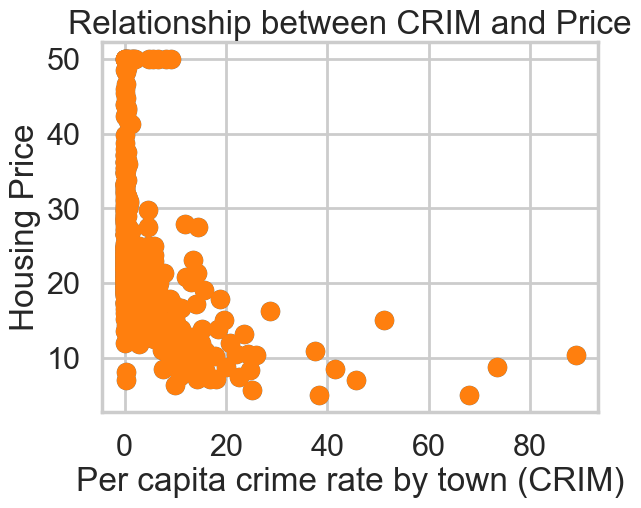

In [6]:
_=plt.scatter(bos.CRIM, bos.PRICE)
_=plt.xlabel("Per capita crime rate by town (CRIM)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between CRIM and Price")
_=plt.show()

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> What kind of relationship do you see? e.g. positive, negative?  linear? non-linear? Is there anything else strange or interesting about the data? What about outliers?</p>


<p><b>Exercise:</b> Create scatter plots between *RM* and *PRICE*, and *PTRATIO* and *PRICE*. Label your axes appropriately using human readable labels. Tell a story about what you see.</p>

<p><b>Exercise:</b> What are some other numeric variables of interest? Why do you think they are interesting? Plot scatterplots with these variables and *PRICE* (house price) and tell a story about what you see.</p>

</div>

# your turn: describe relationship
It seems like CRIM and Price are negatively correlated and have a non linear relationship. While the areas that have almost 0 crime do have some of the highest price points, there is high variability in price points for lower crime rate areas and the high prices completely disappear with increase in crime rate. The non linear trend in decreasing price with increasing crime rate seems to appear as an exponential decay.

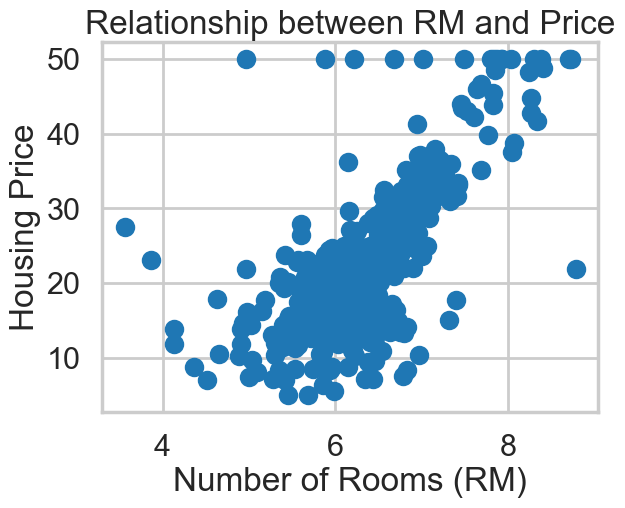

In [7]:
# your turn: scatter plot between *RM* and *PRICE*
_=plt.scatter(bos.RM, bos.PRICE)
_=plt.xlabel("Number of Rooms (RM)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between RM and Price")
_=plt.show()

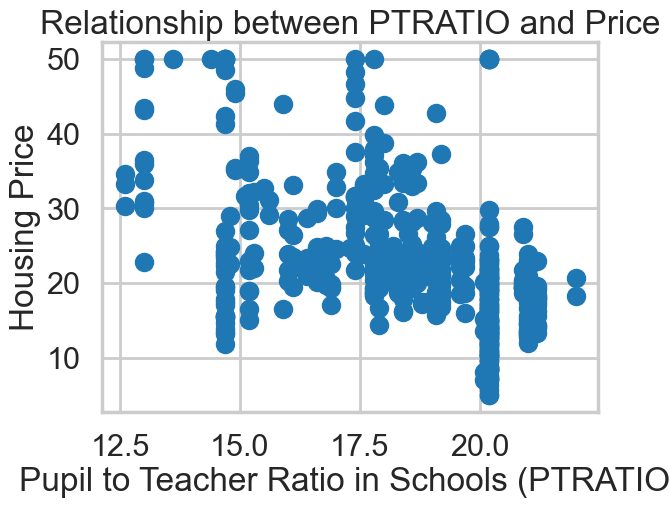

In [8]:
# your turn: scatter plot between *PTRATIO* and *PRICE*
_=plt.scatter(bos.PTRATIO, bos.PRICE)
_=plt.xlabel("Pupil to Teacher Ratio in Schools (PTRATIO)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between PTRATIO and Price")
_=plt.show()

Number of Rooms (RM) and Housing Price (PRICE) seem to have a positive linear relationship with the housing price increasing linearly as number of rooms increase. There are some outliers escpecially where the PRICE seems to be capped at 50. 

It seems like PTRATIO and Price are negatively correlated and have a weaker linear relationship with a higher degree of variance. However, we do see that areas with more number of pupils per teacher genrally have lower house prices.

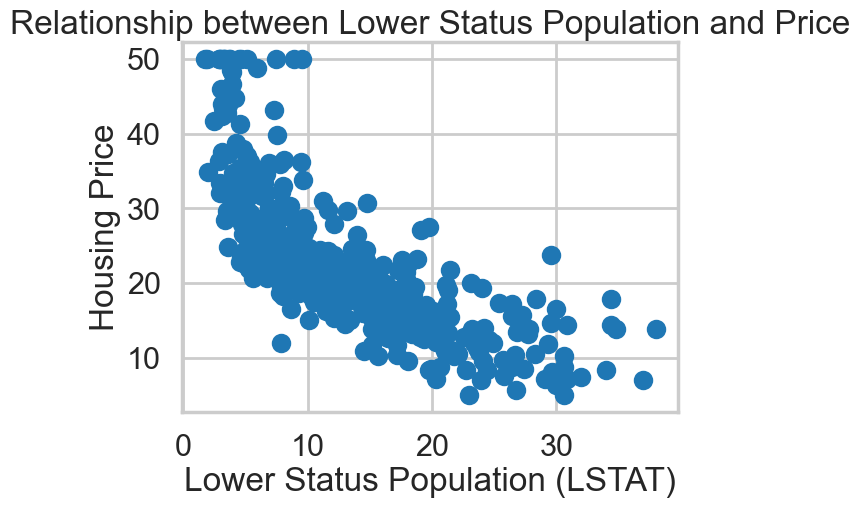

In [9]:
# your turn: create some other scatter plots
# your turn: scatter plot between *LSTAT* and *PRICE*
_=plt.scatter(bos.LSTAT, bos.PRICE)
_=plt.xlabel("Lower Status Population (LSTAT)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between Lower Status Population and Price")
_=plt.show()

There seems to be a strong negative correlation between lower status population and housing prices. Housing prices can be seen decreasing with increase in lower status population. Although, the relationship does not seem very linear.

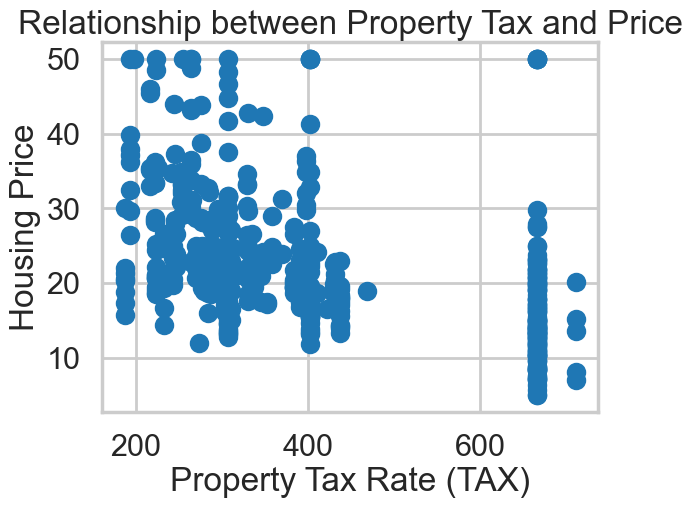

In [22]:
# your turn: scatter plot between *TAX* and *PRICE*
_=plt.scatter(bos.TAX, bos.PRICE)
_=plt.xlabel("Property Tax Rate (TAX)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between Property Tax and Price")
_=plt.show()

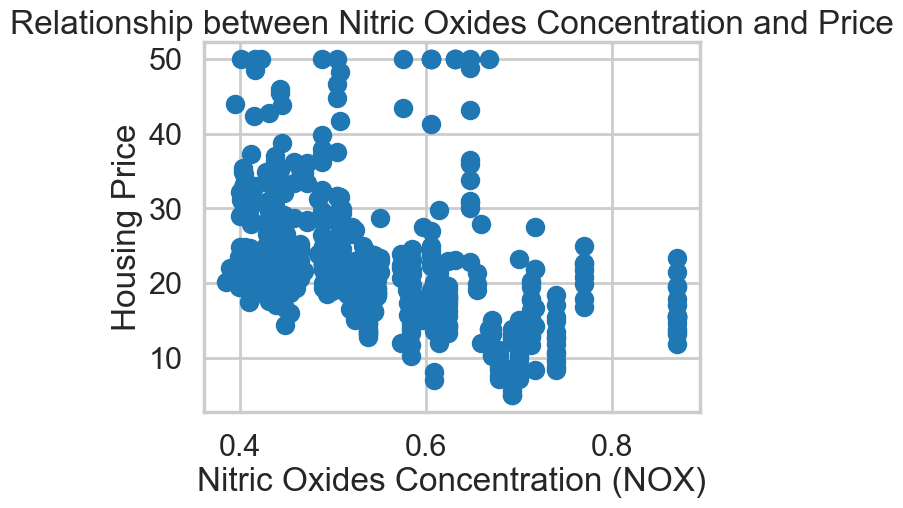

In [12]:
# your turn: scatter plot between *NOX* and *PRICE*
_=plt.scatter(bos.NOX, bos.PRICE)
_=plt.xlabel("Nitric Oxides Concentration (NOX)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between Nitric Oxides Concentration and Price")
_=plt.show()

There seems to be a weak negative correlation between nitric oxide concentration in a area vs. house prices. Housing prices can be seen decreasing with increase in nitric oxide concentration.

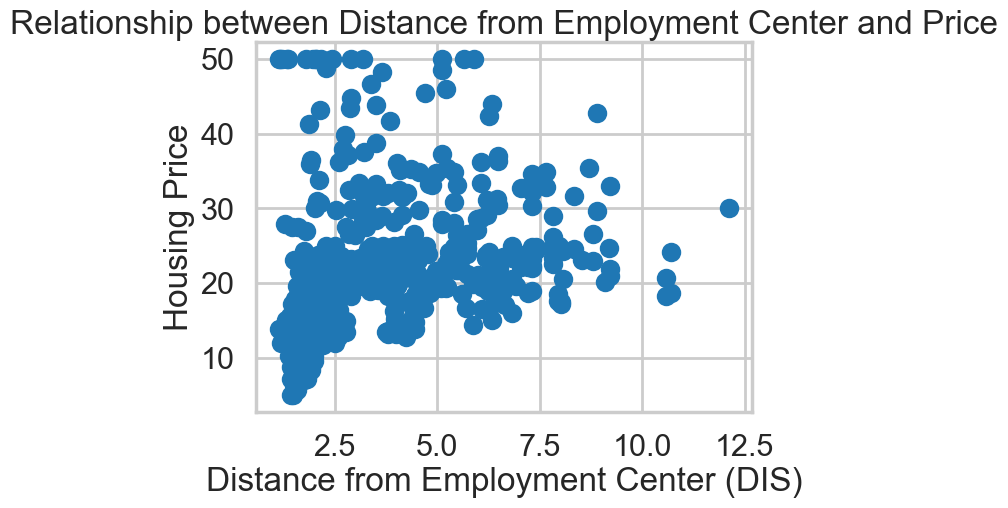

In [13]:
# your turn: scatter plot between *DIS* and *PRICE*
_=plt.scatter(bos.DIS, bos.PRICE)
_=plt.xlabel("Distance from Employment Center (DIS)")
_=plt.ylabel("Housing Price")
_=plt.title("Relationship between Distance from Employment Center and Price")
_=plt.show()

There does not seem to be much of a correlation between distrance from employment center and housing prices.

### Scatterplots using Seaborn
***

[Seaborn](https://stanford.edu/~mwaskom/software/seaborn/) is a cool Python plotting library built on top of matplotlib. It provides convenient syntax and shortcuts for many common types of plots, along with better-looking defaults.

We can also use [seaborn regplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/regression.html#functions-to-draw-linear-regression-models) for the scatterplot above. This provides automatic linear regression fits (useful for data exploration later on). Here's one example below.

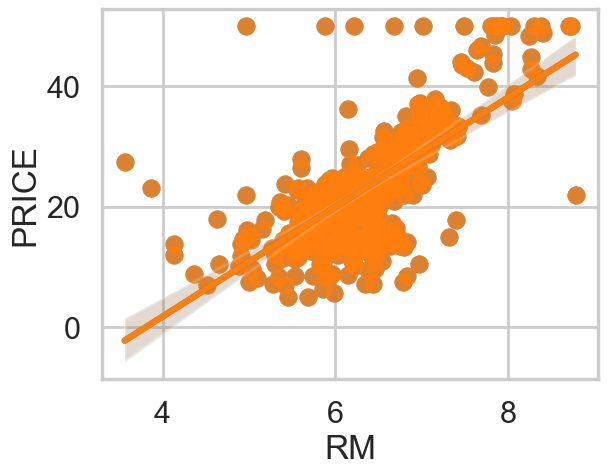

In [16]:
sns.regplot(y="PRICE", x="RM", data=bos, fit_reg = True)
plt.show()

### Histograms
***


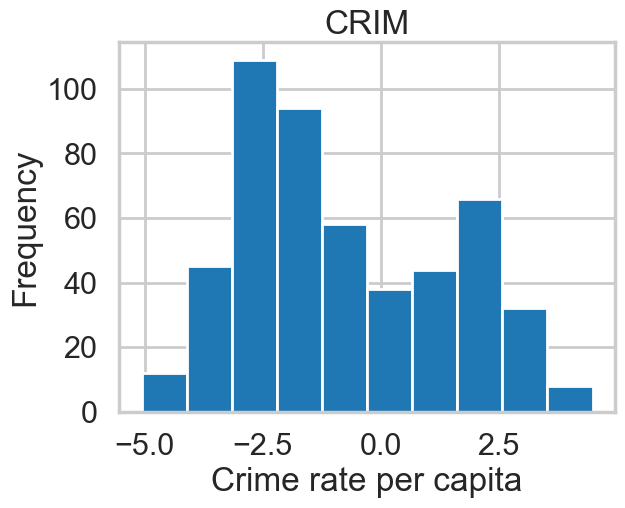

In [17]:
plt.hist(np.log(bos.CRIM))
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequency")
plt.show()

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> In the above histogram, we took the logarithm of the crime rate per capita. Repeat this histogram without taking the log. What was the purpose of taking the log? What do we gain by making this transformation? What do you now notice about this variable that is not obvious without making the transformation?

<p><b>Exercise:</b> Plot the histogram for *RM* and *PTRATIO* against each other, along with the two variables you picked in the previous section. We are looking for correlations in predictors here.</p>
</div>

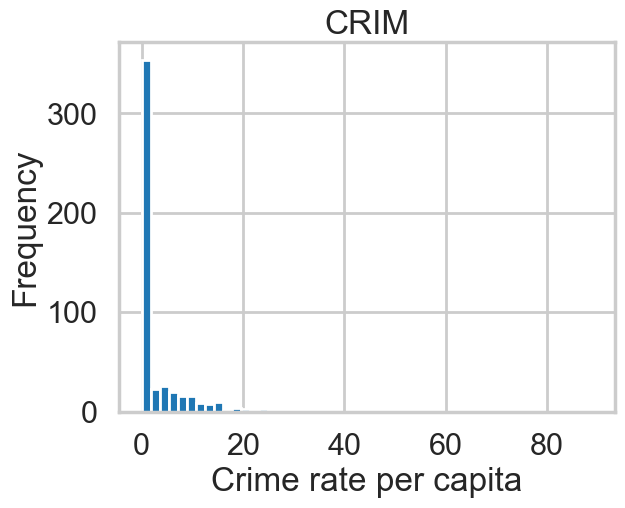

In [21]:
#your turn
plt.hist(bos.CRIM, bins = 50)
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequency")
plt.show()

Histogram of Crime Rate per Capita without taking a log is highly right skewed because most of the areas have lower crime rates but we also have very few areas ranging from 20 all the way upto 80. Taking a log normalizes this distribution, and makes it more readable with low crime areas more spread out and high crime areas shown more tightly together.

## Part 3: Linear Regression with Boston Housing Data Example
***

Here, 

$Y$ = boston housing prices (called "target" data in python, and referred to as the dependent variable or response variable)

and

$X$ = all the other features (or independent variables, predictors or explanatory variables)

which we will use to fit a linear regression model and predict Boston housing prices. We will use the least-squares method to estimate the coefficients.  

We'll use two ways of fitting a linear regression. We recommend the first but the second is also powerful in its features.

### Fitting Linear Regression using `statsmodels`
***
[Statsmodels](http://statsmodels.sourceforge.net/) is a great Python library for a lot of basic and inferential statistics. It also provides basic regression functions using an R-like syntax, so it's commonly used by statisticians. While we don't cover statsmodels officially in the Data Science Intensive workshop, it's a good library to have in your toolbox. Here's a quick example of what you could do with it. The version of least-squares we will use in statsmodels is called *ordinary least-squares (OLS)*. There are many other versions of least-squares such as [partial least squares (PLS)](https://en.wikipedia.org/wiki/Partial_least_squares_regression) and [weighted least squares (WLS)](https://en.wikipedia.org/wiki/Iteratively_reweighted_least_squares).

In [24]:
# Import regression modules
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [25]:
# statsmodels works nicely with pandas dataframes
# The thing inside the "quotes" is called a formula, a bit on that below
m = ols('PRICE ~ RM',bos).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           2.49e-74
Time:                        15:49:25   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.0

#### Interpreting coefficients

There is a ton of information in this output. But we'll concentrate on the coefficient table (middle table). We can interpret the `RM` coefficient (9.1021) by first noticing that the p-value (under `P>|t|`) is so small, basically zero. This means that the number of rooms, `RM`, is a statisticall significant predictor of `PRICE`. The regression coefficient for `RM` of 9.1021 means that *on average, each additional room is associated with an increase of $\$9,100$ in house price net of the other variables*. The confidence interval gives us a range of plausible values for this average change, about ($\$8,279, \$9,925$), definitely not chump change. 

In general, the $\hat{\beta_i}, i > 0$ can be interpreted as the following: "A one unit increase in $x_i$ is associated with, on average, a $\hat{\beta_i}$ increase/decrease in $y$ net of all other variables."

On the other hand, the interpretation for the intercept, $\hat{\beta}_0$ is the average of $y$ given that all of the independent variables $x_i$ are 0.

####  `statsmodels` formulas
***
This formula notation will seem familiar to `R` users, but will take some getting used to for people coming from other languages or are new to statistics.

The formula gives instruction for a general structure for a regression call. For `statsmodels` (`ols` or `logit`) calls you need to have a Pandas dataframe with column names that you will add to your formula. In the below example you need a pandas data frame that includes the columns named (`Outcome`, `X1`,`X2`, ...), but you don't need to build a new dataframe for every regression. Use the same dataframe with all these things in it. The structure is very simple:

`Outcome ~ X1`

But of course we want to to be able to handle more complex models, for example multiple regression is doone like this:

`Outcome ~ X1 + X2 + X3`

In general, a formula for an OLS multiple linear regression is

`Y ~ X1 + X2 + ... + Xp`

This is the very basic structure but it should be enough to get you through the homework. Things can get much more complex. You can force statsmodels to treat variables as categorical with the `C()` function, call numpy functions to transform data such as `np.log` for extremely-skewed data, or fit a model without an intercept by including `- 1` in the formula. For a quick run-down of further uses see the `statsmodels` [help page](http://statsmodels.sourceforge.net/devel/example_formulas.html).


Let's see how our model actually fit our data. We can see below that there is a ceiling effect, we should probably look into that. Also, for large values of $Y$ we get underpredictions, most predictions are below the 45-degree gridlines. 

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a scatterplot between the predicted prices, available in `m.fittedvalues` (where `m` is the fitted model) and the original prices. How does the plot look? Do you notice anything interesting or weird in the plot? Comment on what you see.</p>
</div>

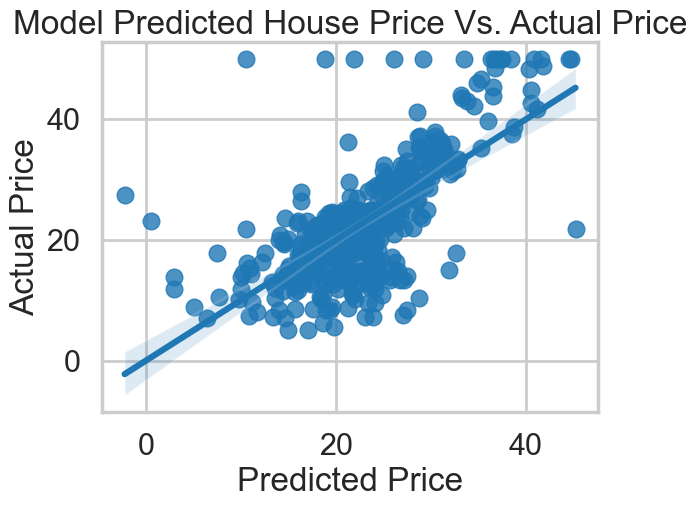

In [35]:
# your turn
#_=plt.scatter(m.fittedvalues, bos.PRICE)
sns.regplot(y="PRICE", x=m.fittedvalues, data=bos, fit_reg = True)
plt.title("Model Predicted House Price Vs. Actual Price")
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
_=plt.show()

### Fitting Linear Regression using `sklearn`


In [36]:
from sklearn.linear_model import LinearRegression
X = bos.drop('PRICE', axis = 1)

# This creates a LinearRegression object
lm = LinearRegression()
lm

LinearRegression()

#### What can you do with a LinearRegression object? 
***
Check out the scikit-learn [docs here](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). We have listed the main functions here. Most machine learning models in scikit-learn follow this same API of fitting a model with `fit`, making predictions with `predict` and the appropriate scoring function `score` for each model.

Main functions | Description
--- | --- 
`lm.fit()` | Fit a linear model
`lm.predit()` | Predict Y using the linear model with estimated coefficients
`lm.score()` | Returns the coefficient of determination (R^2). *A measure of how well observed outcomes are replicated by the model, as the proportion of total variation of outcomes explained by the model*

#### What output can you get?

In [45]:
# Look inside lm object
lm.coef_
lm.intercept_

np.float64(36.45948838509)

Output | Description
--- | --- 
`lm.coef_` | Estimated coefficients
`lm.intercept_` | Estimated intercept 

### Fit a linear model
***

The `lm.fit()` function estimates the coefficients the linear regression using least squares. 

In [46]:
# Use all 13 predictors to fit linear regression model
lm.fit(X, bos.PRICE)

LinearRegression()

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> How would you change the model to not fit an intercept term? Would you recommend not having an intercept? Why or why not? For more information on why to include or exclude an intercept, look [here](https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faq-what-is-regression-through-the-origin/).</p>

<p><b>Exercise:</b> One of the assumptions of the linear model is that the residuals must be i.i.d. (independently and identically distributed). To satisfy this, is it enough that the residuals are normally distributed? Explain your answer.</p>

<p><b>Exercise:</b> True or false. To use linear regression, $Y$ must be normally distributed. Explain your answer.</p>
</div>

# your turn
<p><b>Exercise 1:</b> To change the model to not fit an intercept term, we would define lm as lm = LinearRegression(fit_intercept = False). I would not recommend removing the intercept as it would mean that a house with zero predictors would have zero value which might be unrealistic and we may end up impacting the model adversely. 

<p><b>Exercise 2:</b> It is not enough that the residuals are normally distributed since it does not gurantee that the residuals are independent i.e. the error in one residual does not predict the error in another one. It also does not guarantee that they are identifcally distributed i.e. they have the same variance across all predictors.

<p><b>Exercise 3:</b> False. The assumption when using linear regression is that the residuals are normally disctributed not Y whose distribution depends on the distribution of predictors plus the error.

### Estimated intercept and coefficients

Let's look at the estimated coefficients from the linear model using `1m.intercept_` and `lm.coef_`.  

After we have fit our linear regression model using the least squares method, we want to see what are the estimates of our coefficients $\beta_0$, $\beta_1$, ..., $\beta_{13}$: 

$$ \hat{\beta}_0, \hat{\beta}_1, \ldots, \hat{\beta}_{13} $$



In [48]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 36.45948838509


In [49]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 13


In [50]:
# The coefficients
pd.DataFrame({'features': X.columns, 'estimatedCoefficients': lm.coef_})[['features', 'estimatedCoefficients']]

,features,estimatedCoefficients
0,CRIM,-0.108011
1,ZN,0.046420
2,INDUS,0.020559
3,CHAS,2.686734
4,NOX,-17.766611
5,RM,3.809865
6,AGE,0.000692
7,DIS,-1.475567
8,RAD,0.306049
9,TAX,-0.012335


### Predict Prices 

We can calculate the predicted prices ($\hat{Y}_i$) using `lm.predict`. 

$$ \hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \ldots \hat{\beta}_{13} X_{13} $$

In [51]:
# first five predicted prices
lm.predict(X)[0:5]

array([30.00384338, 25.02556238, 30.56759672, 28.60703649, 27.94352423])

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Histogram: Plot a histogram of all the predicted prices. Write a story about what you see. Describe the shape, center and spread of the distribution. Are there any outliers? What might be the reason for them? Should we do anything special with them?</p>

<p><b>Exercise:</b> Scatterplot: Let's plot the true prices compared to the predicted prices to see they disagree (we did this with `statsmodels` before).</p>

<p><b>Exercise:</b> We have looked at fitting a linear model in both `statsmodels` and `scikit-learn`. What are the advantages and disadvantages of each based on your exploration? Based on the information provided by both packages, what advantage does `statsmodels` provide?</p>
</div>

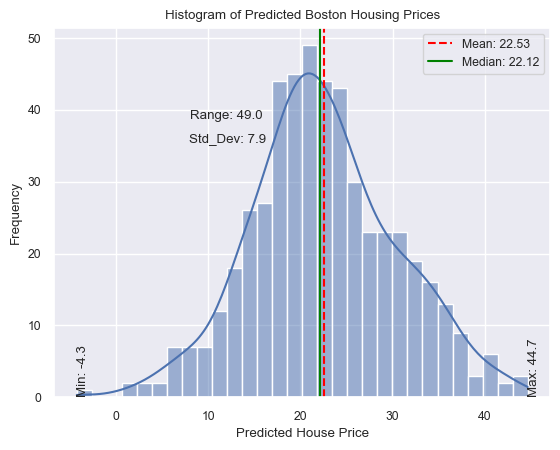

In [101]:
# your turn
sns.set(font_scale=0.8)
_=sns.histplot(lm.predict(X), bins = 30, kde = True)
_=plt.title("Histogram of Predicted Boston Housing Prices")
_=plt.xlabel("Predicted House Price")
_=plt.ylabel("Frequency")
_=plt.axvline(np.mean(lm.predict(X)), color='red', linestyle='--', label=f'Mean: {np.mean(lm.predict(X)):.2f}')
_=plt.axvline(np.median(lm.predict(X)), color='green', linestyle='-', label=f'Median: {np.median(lm.predict(X)):.2f}')
_=plt.text(np.min(lm.predict(X)), 0, f'Min: {np.min(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(np.max(lm.predict(X)), 0, f'Max: {np.max(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(np.std(lm.predict(X)), 35, f'Std_Dev: {np.std(lm.predict(X)):.1f}',rotation=0, verticalalignment='bottom')
_=plt.text(8, 40, f'Range: {np.max(lm.predict(X)) - np.min(lm.predict(X)):.1f}',rotation=0, verticalalignment='top')
_=plt.legend(loc='upper right')
plt.show()

<p><b>Exercise:</b> Histogram: Plot a histogram of all the predicted prices. Write a story about what you see. Describe the shape, center and spread of the distribution. Are there any outliers? What might be the reason for them? Should we do anything special with them?

The model predictions form a symmetrical, bell shaped distribution, very close to the normal distribution with the center of distribution very close to the mean of 22.53 (in 1000's of dollars). The median house price (22.12 (in 1000's of dollars)) is also very close to the mean indicating symmetric distribution. The standard deviation of 7.8 (in 1000's of dollars) indicates how much the individual prices deviate from the mean.  Most of the house prices seem to be in the 15 to 30 (in 1000's of dollars) range. We do see extremely values (outliers). The lower one at -4.3 is certainly an erroneous prediction potentially due to extreme values of predictors and the linear nature of the model. We can potentially fix this by either applying a log transformation to price values before modeling them or using a linear regression model that constrains price to be a positive value only. Higher extreme end predictions by the model like 44.7 might be due to the dataset being capped at 50. For now we will not do anything special with them.

### Evaluating the Model: Sum-of-Squares

The partitioning of the sum-of-squares shows the variance in the predictions explained by the model and the variance that is attributed to error.

$$TSS = ESS + RSS$$

#### Residual Sum-of-Squares (aka $RSS$)

The residual sum-of-squares is one of the basic ways of quantifying how much error exists in the fitted model. We will revisit this in a bit.

$$ RSS = \sum_{i=1}^N r_i^2 = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

In [102]:
print(np.sum((bos.PRICE - lm.predict(X)) ** 2))

11078.784577954977


#### Explained Sum-of-Squares (aka $ESS$)

The explained sum-of-squares measures the variance explained by the regression model.

$$ESS = \sum_{i=1}^N \left( \hat{y}_i - \bar{y} \right)^2 = \sum_{i=1}^N \left( \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) - \bar{y} \right)^2$$

In [104]:
print(np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))

31637.510837064823


### Evaluating the Model: The Coefficient of Determination ($R^2$)

The coefficient of determination, $R^2$, tells us the percentage of the variance in the response variable $Y$ that can be explained by the linear regression model.

$$ R^2 = \frac{ESS}{TSS} $$

The $R^2$ value is one of the most common metrics that people use in describing the quality of a model, but it is important to note that *$R^2$ increases artificially as a side-effect of increasing the number of independent variables.* While $R^2$ is reported in almost all statistical packages, another metric called the *adjusted $R^2$* is also provided as it takes into account the number of variables in the model, and can sometimes even be used for non-linear regression models!

$$R_{adj}^2 = 1 - \left( 1 - R^2 \right) \frac{N - 1}{N - K - 1} = R^2 - \left( 1 - R^2 \right) \frac{K}{N - K - 1} = 1 - \frac{\frac{RSS}{DF_R}}{\frac{TSS}{DF_T}}$$

where $N$ is the number of observations, $K$ is the number of variables, $DF_R = N - K - 1$ is the degrees of freedom associated with the residual error and $DF_T = N - 1$ is the degrees of the freedom of the total error.

### Evaluating the Model: Mean Squared Error and the $F$-Statistic
***
The mean squared errors are just the *averages* of the sum-of-squares errors over their respective degrees of freedom.

$$MSE = \frac{RSS}{N-K-1}$$

$$MSR = \frac{ESS}{K}$$

**Remember:** Notation may vary across resources particularly the use of $R$ and $E$ in $RSS/ESS$ and $MSR/MSE$. In some resources, E = explained and R = residual. In other resources, E = error and R = regression (explained). **This is a very important distinction that requires looking at the formula to determine which naming scheme is being used.**

Given the MSR and MSE, we can now determine whether or not the entire model we just fit is even statistically significant. We use an $F$-test for this. The null hypothesis is that all of the $\beta$ coefficients are zero, that is, none of them have any effect on $Y$. The alternative is that *at least one* $\beta$ coefficient is nonzero, but it doesn't tell us which one in a multiple regression:

$$H_0: \beta_i = 0, \mbox{for all $i$} \\
H_A: \beta_i > 0, \mbox{for some $i$}$$ 

$$F = \frac{MSR}{MSE} = \left( \frac{R^2}{1 - R^2} \right) \left( \frac{N - K - 1}{K} \right)$$
 
Once we compute the $F$-statistic, we can use the $F$-distribution with $N-K$ and $K-1$ degrees of degrees of freedom to get a p-value.

**Warning!** The $F$-statistic mentioned in this section is NOT the same as the F1-measure or F1-value discused in Unit 7.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set IV</h3>

<p>Let's look at the relationship between `PTRATIO` and housing price.</p>

<p><b>Exercise:</b> Try fitting a linear regression model using only the 'PTRATIO' (pupil-teacher ratio by town) and interpret the intercept and the coefficients.</p>

<p><b>Exercise:</b> Calculate (or extract) the $R^2$ value. What does it tell you?</p>

<p><b>Exercise:</b> Compute the $F$-statistic. What does it tell you?</p>

<p><b>Exercise:</b> Take a close look at the $F$-statistic and the $t$-statistic for the regression coefficient. What relationship do you notice? Note that this relationship only applies in *simple* linear regression models.</p>
</div>

In [105]:
# your turn
X = bos[['PTRATIO']]

# This creates a LinearRegression object
lm = LinearRegression()
lm

LinearRegression()

In [106]:
# Use PTRATIO predictor to fit linear regression model
lm.fit(X, bos.PRICE)

LinearRegression()

In [107]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 62.344627474832635


In [108]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 1


In [110]:
# The coefficient
pd.DataFrame({'feature': X.columns, 'estimatedCoefficient': lm.coef_})[['feature', 'estimatedCoefficient']]

,feature,estimatedCoefficient
0,PTRATIO,-2.157175


<p><b>Exercise:</b> Try fitting a linear regression model using only the 'PTRATIO' (pupil-teacher ratio by town) and interpret the intercept and the coefficients.</p>

The intercept coefficient of 62.34 tells us what the median house price would be when PTRATIO is zero. It shows a baseline price in the linear regression equation.

The coefficient of -2.15 indicates that for every unit increase in Pupil to Teacher Ratio, we expect to see a decline of -2.15($2,150) in median housing price.

In [111]:
# first five predicted prices
lm.predict(X)[0:5]

array([29.33984545, 23.9469072 , 23.9469072 , 22.00544944, 22.00544944])

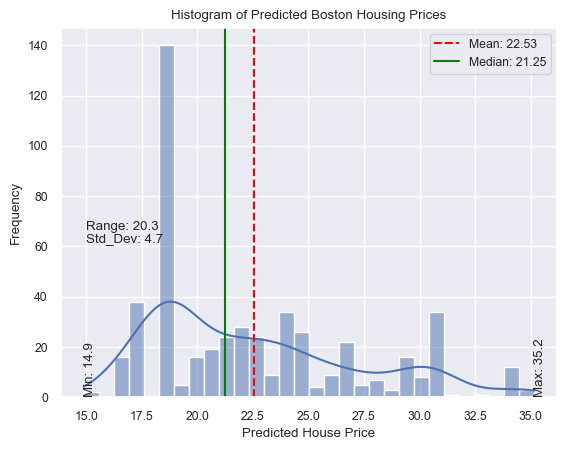

In [132]:
# your turn
sns.set(font_scale=0.8)
_=sns.histplot(lm.predict(X), bins = 30, kde = True)
_=plt.title("Histogram of Predicted Boston Housing Prices")
_=plt.xlabel("Predicted House Price")
_=plt.ylabel("Frequency")
_=plt.axvline(np.mean(lm.predict(X)), color='red', linestyle='--', label=f'Mean: {np.mean(lm.predict(X)):.2f}')
_=plt.axvline(np.median(lm.predict(X)), color='green', linestyle='-', label=f'Median: {np.median(lm.predict(X)):.2f}')
_=plt.text(np.min(lm.predict(X)), 0, f'Min: {np.min(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(np.max(lm.predict(X)), 0, f'Max: {np.max(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(15, 60, f'Std_Dev: {np.std(lm.predict(X)):.1f}',rotation=0, verticalalignment='bottom')
_=plt.text(15, 70, f'Range: {np.max(lm.predict(X)) - np.min(lm.predict(X)):.1f}',rotation=0, verticalalignment='top')
_=plt.legend(loc='upper right')
plt.show()

In [120]:
#Calculating r_squared
print((np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))/((np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))+(np.sum((bos.PRICE - lm.predict(X)) ** 2))))
#Using score feature
r_squared=lm.score(X,bos['PRICE'] )
print(r_squared)

0.2578473180092225
0.257847318009223


<p><b>Exercise:</b> Calculate (or extract) the $R^2$ value. What does it tell you?
$R^2$ value of ~.26 (26%) tells us that PTRATIO alone as a predictor variable can predict only 26% of the variance in boston housing prices.

In [125]:
#Calculating F Statistic
F_Statistic = len(bos['PRICE'])*r_squared/(1-r_squared)
print(F_Statistic)

175.80040614107523


In [127]:
#Calculating F Statistic using statsmodels
X_sm = sm.add_constant(X)
lm_sm = sm.OLS(bos.PRICE, X_sm).fit()
print(lm_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     175.1
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.61e-34
Time:                        19:54:29   Log-Likelihood:                -1764.8
No. Observations:                 506   AIC:                             3534.
Df Residuals:                     504   BIC:                             3542.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.3446      3.029     20.581      0.0

<p><b>Exercise:</b> Compute the $F$-statistic. What does it tell you?</p>

The $F$-statistic of 175.1 with a very low P value of almost 0 tells us that our model is statistically significant. PTRATIO does seems to be influencing housing prices and that the results are not due to pure chance.

<p><b>Exercise:</b> Take a close look at the $F$-statistic and the $t$-statistic for the regression coefficient. What relationship do you notice? Note that this relationship only applies in *simple* linear regression models.</p>
</div>

The $F$-statistic and the $t$-statistic for the regression coefficient show that $F$-statistic value of 175.1 is the square of $t$-statistic value of -13.233 from the statsmodel summary. Upon reading more about this relationship, the learning is that for simple linear regression models with only one predictor, $F$-statistic is indeed the square of $t$-statistic.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set V</h3>

<p>Fit a linear regression model using three independent variables</p>

<ol>
<li> 'CRIM' (per capita crime rate by town)
<li> 'RM' (average number of rooms per dwelling)
<li> 'PTRATIO' (pupil-teacher ratio by town)
</ol>

<p><b>Exercise:</b> Compute or extract the $F$-statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Compute or extract the $R^2$ statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Which variables in the model are significant in predicting house price? Write a story that interprets the coefficients.</p>
</div>

In [133]:
# your turn
X = bos[['CRIM','RM','PTRATIO']]

# This creates a LinearRegression object
lm = LinearRegression()
lm

LinearRegression()

In [134]:
# Using CRIM, RM & PTRATIO predictor to fit linear regression model
lm.fit(X, bos.PRICE)
print('Estimated intercept coefficient: {}'.format(lm.intercept_))
print('Number of coefficients: {}'.format(len(lm.coef_)))
# The coefficient
print(pd.DataFrame({'feature': X.columns, 'estimatedCoefficient': lm.coef_})[['feature', 'estimatedCoefficient']]) 

Estimated intercept coefficient: -3.3707043351542367
Number of coefficients: 3
   feature  estimatedCoefficient
0     CRIM             -0.204961
1       RM              7.380411
2  PTRATIO             -1.069546


In [135]:
# first five predicted prices
lm.predict(X)[0:5]

array([28.79014801, 24.97539733, 30.61403551, 28.27026594, 29.36242923])

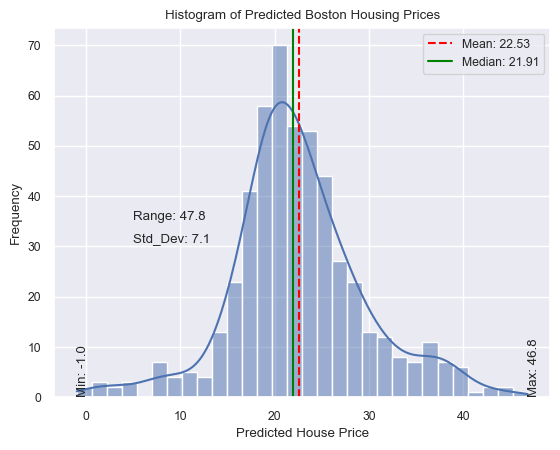

In [139]:
# your turn
sns.set(font_scale=0.8)
_=sns.histplot(lm.predict(X), bins = 30, kde = True)
_=plt.title("Histogram of Predicted Boston Housing Prices")
_=plt.xlabel("Predicted House Price")
_=plt.ylabel("Frequency")
_=plt.axvline(np.mean(lm.predict(X)), color='red', linestyle='--', label=f'Mean: {np.mean(lm.predict(X)):.2f}')
_=plt.axvline(np.median(lm.predict(X)), color='green', linestyle='-', label=f'Median: {np.median(lm.predict(X)):.2f}')
_=plt.text(np.min(lm.predict(X)), 0, f'Min: {np.min(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(np.max(lm.predict(X)), 0, f'Max: {np.max(lm.predict(X)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(5, 30, f'Std_Dev: {np.std(lm.predict(X)):.1f}',rotation=0, verticalalignment='bottom')
_=plt.text(5, 37, f'Range: {np.max(lm.predict(X)) - np.min(lm.predict(X)):.1f}',rotation=0, verticalalignment='top')
_=plt.legend(loc='upper right')
plt.show()

In [140]:
#Calculating r_squared
print((np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))/((np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))+(np.sum((bos.PRICE - lm.predict(X)) ** 2))))
#Using score feature
r_squared=lm.score(X,bos['PRICE'] )
print(r_squared)

0.5943412940723469
0.5943412940723471


In [144]:
#Calculating F Statistic
F_Statistic = ((len(bos['PRICE'])-2)/3)*(r_squared/(1-r_squared))
print(F_Statistic)

246.14124125801936


In [142]:
#Calculating F Statistic using statsmodels
X_sm = sm.add_constant(X)
lm_sm = sm.OLS(bos.PRICE, X_sm).fit()
print(lm_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     245.2
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           6.15e-98
Time:                        15:19:21   Log-Likelihood:                -1612.0
No. Observations:                 506   AIC:                             3232.
Df Residuals:                     502   BIC:                             3249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3707      4.034     -0.836      0.4

<p><b>Exercise:</b> Compute or extract the $F$-statistic. What does it tell you about the model?

The $F$-statistic value is high (245.2) with a very small p-value of almost 0 suggesting the our linear regression model with CRIM, RM, PTRATIO as predictors is significantly better at predicting housing prices than no indicators. So, we can reject the null hypothesis and say that these 3 variables have an impact on housing prices. 

<p><b>Exercise:</b> Compute or extract the $R^2$ statistic. What does it tell you about the model?</p>

The $R^2$ statistic of 0.594 (59.4%) tells us how much of the variance in the housing prices can be predicted by the combination of these 3 variables (CRIM, RM and PTRATIO).

<p><b>Exercise:</b> Which variables in the model are significant in predicting house price? Write a story that interprets the coefficients.</p>

For all the 3 predictor variables, the p value is almost zero suggesting that all of them have a significant impact on housing price. 

Based on the coefficients and knowing that prices are listing in 1000's of dollars, we can say that 
<p>For every unit increase in Crime Rate Per Capita, the house prices decrease by dollar 205 (since -0.205 is the coef).<p>
<p>For every unit increase in Rooms, the house prices increase by dollar 7380 (since 7.3804 is the coef).<p>
<p>For every unit increase in Pupil to Teacher ratio, the house prices decrease by dollar 1069.5 (since -1.0695 is the coef).<p>

## Part 4: Comparing Models

During modeling, there will be times when we want to compare models to see which one is more predictive or fits the data better. There are many ways to compare models, but we will focus on two.

### The $F$-Statistic Revisited

The $F$-statistic can also be used to compare two *nested* models, that is, two models trained on the same dataset where one of the models contains a *subset* of the variables of the other model. The *full* model contains $K$ variables and the *reduced* model contains a subset of these $K$ variables. This allows us to add additional variables to a base model and then test if adding the variables helped the model fit.

$$F = \frac{\left( \frac{RSS_{reduced} - RSS_{full}}{DF_{reduced} - DF_{full}} \right)}{\left( \frac{RSS_{full}}{DF_{full}} \right)}$$

where $DF_x = N - K_x - 1$ where $K_x$ is the number of variables in model $x$.

### Akaike Information Criterion (AIC)

Another statistic for comparing two models is AIC, which is based on the likelihood function and takes into account the number of variables in the model.

$$AIC = 2 K - 2 \log_e{L}$$

where $L$ is the likelihood of the model. AIC is meaningless in the absolute sense, and is only meaningful when compared to AIC values from other models. Lower values of AIC indicate better fitting models.

`statsmodels` provides the AIC in its output.

<div class="span5 alert alert-info">
<h3>Part 4 Checkup Exercises</h3>

<p><b>Exercise:</b> Find another variable (or two) to add to the model we built in Part 3. Compute the $F$-test comparing the two models as well as the AIC. Which model is better?</p>
</div>

In [148]:
#Let us add LSTAT to the model
X1 = bos[['CRIM','RM','PTRATIO','LSTAT']]

# This creates a LinearRegression object
lm1 = LinearRegression()
lm1

LinearRegression()

In [149]:
# Using CRIM, RM, PTRATIO & LSTAT as predictors to fit linear regression model
lm1.fit(X1, bos.PRICE)
print('Estimated intercept coefficient: {}'.format(lm1.intercept_))
print('Number of coefficients: {}'.format(len(lm1.coef_)))
# The coefficient
print(pd.DataFrame({'feature': X1.columns, 'estimatedCoefficient': lm1.coef_})[['feature', 'estimatedCoefficient']]) 

Estimated intercept coefficient: 16.923298191930765
Number of coefficients: 4
   feature  estimatedCoefficient
0     CRIM             -0.065438
1       RM              4.618624
2  PTRATIO             -0.889689
3    LSTAT             -0.534313


In [150]:
# first five predicted prices
lm1.predict(X1)[0:5]

array([31.01720865, 25.85760063, 32.11657106, 31.03423699, 30.44300304])

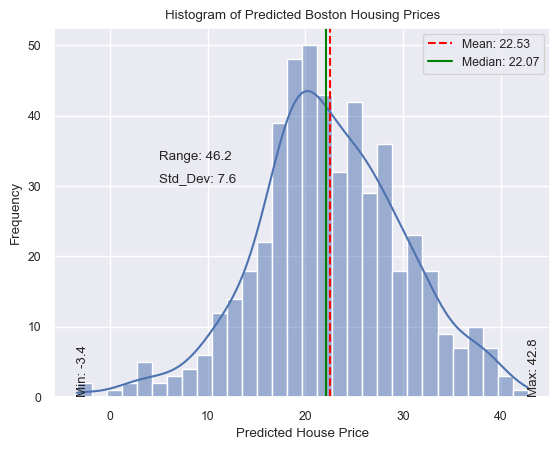

In [153]:
# your turn
sns.set(font_scale=0.8)
_=sns.histplot(lm1.predict(X1), bins = 30, kde = True)
_=plt.title("Histogram of Predicted Boston Housing Prices")
_=plt.xlabel("Predicted House Price")
_=plt.ylabel("Frequency")
_=plt.axvline(np.mean(lm1.predict(X1)), color='red', linestyle='--', label=f'Mean: {np.mean(lm1.predict(X1)):.2f}')
_=plt.axvline(np.median(lm1.predict(X1)), color='green', linestyle='-', label=f'Median: {np.median(lm1.predict(X1)):.2f}')
_=plt.text(np.min(lm1.predict(X1)), 0, f'Min: {np.min(lm1.predict(X1)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(np.max(lm1.predict(X1)), 0, f'Max: {np.max(lm1.predict(X1)):.1f}', rotation=90, verticalalignment='bottom')
_=plt.text(5, 30, f'Std_Dev: {np.std(lm1.predict(X1)):.1f}',rotation=0, verticalalignment='bottom')
_=plt.text(5, 35, f'Range: {np.max(lm1.predict(X1)) - np.min(lm1.predict(X1)):.1f}',rotation=0, verticalalignment='top')
_=plt.legend(loc='upper right')
plt.show()

In [154]:
#Calculating r_squared
print((np.sum((lm1.predict(X1) - np.mean(bos.PRICE)) ** 2))/((np.sum((lm1.predict(X1) - np.mean(bos.PRICE)) ** 2))+(np.sum((bos.PRICE - lm1.predict(X1)) ** 2))))
#Using score feature
r_squared1=lm1.score(X1,bos['PRICE'] )
print(r_squared1)

0.6814923476854235
0.6814923476854233


In [155]:
#Calculating F Statistic
F_Statistic1 = ((len(bos['PRICE'])-3)/4)*(r_squared1/(1-r_squared1))
print(F_Statistic1)

269.0599805018248


In [156]:
#Calculating F Statistic using statsmodels
X1_sm = sm.add_constant(X1)
lm1_sm = sm.OLS(bos.PRICE, X1_sm).fit()
print(lm1_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     268.0
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          5.84e-123
Time:                        16:37:28   Log-Likelihood:                -1550.8
No. Observations:                 506   AIC:                             3112.
Df Residuals:                     501   BIC:                             3133.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.9233      3.976      4.257      0.0

In [169]:
#Ftest comparing the 2 models
RSS_reduced = np.sum((bos.PRICE - lm.predict(X)) ** 2)
RSS_full = np.sum((bos.PRICE - lm1.predict(X1)) ** 2)
DF_reduced = len(bos['PRICE'])-3-1
DF_full = len(bos['PRICE'])-4-1 
F_Test = ((RSS_reduced - RSS_full)/(DF_reduced - DF_full))*(DF_full/RSS_full)
print(F_Test)

137.08517689561617


In [164]:
#FTest using Statsmodels
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(lm_sm, lm1_sm)
print(anova_results)

   df_resid           ssr  df_diff      ss_diff           F        Pr(>F)
0     502.0  17328.237120      0.0          NaN         NaN           NaN
1     501.0  13605.466968      1.0  3722.770152  137.085177  3.714456e-28


<p><b>Exercise:</b> Find another variable (or two) to add to the model we built in Part 3. Compute the $F$-test comparing the two models as well as the AIC. Which model is better?</p>
</div>

The Ftest value is 137 which is much greater than 1 and the p-value (Pr(>F) is almost 0 indicating the the larger model with the extra variable of LSTAT added is better. 

Also, the AIC for full model (3112) is lower than the AIC for reduced model (3232) as can be seen in the statsmodels summary output. This again indicates that adding this additional variable of LSTAT improves our model (provides a better fitting model) in predicting house prices.


## Part 5: Evaluating the Model via Model Assumptions and Other Issues
***
Linear regression makes several assumptions. It is always best to check that these assumptions are valid after fitting a linear regression model.

<div class="span5 alert alert-danger">
<ul>
  <li>**Linearity**. The dependent variable $Y$ is a linear combination of the regression coefficients and the independent variables $X$. This can be verified with a scatterplot of each $X$ vs. $Y$ and plotting correlations among $X$. Nonlinearity can sometimes be resolved by [transforming](https://onlinecourses.science.psu.edu/stat501/node/318) one or more independent variables, the dependent variable, or both. In other cases, a [generalized linear model](https://en.wikipedia.org/wiki/Generalized_linear_model) or a [nonlinear model](https://en.wikipedia.org/wiki/Nonlinear_regression) may be warranted.</li>
  <li>**Constant standard deviation**. The SD of the dependent variable $Y$ should be constant for different values of X. We can check this by plotting each $X$ against $Y$ and verifying that there is no "funnel" shape showing data points fanning out as $X$ increases or decreases. Some techniques for dealing with non-constant variance include weighted least squares (WLS), [robust standard errors](https://en.wikipedia.org/wiki/Heteroscedasticity-consistent_standard_errors), or variance stabilizing transformations.
    </li>
  <li> **Normal distribution for errors**.  The $\epsilon$ term we discussed at the beginning are assumed to be normally distributed. This can be verified with a fitted values vs. residuals plot and verifying that there is no pattern, and with a quantile plot.
  $$ \epsilon_i \sim N(0, \sigma^2)$$
Sometimes the distributions of responses $Y$ may not be normally distributed at any given value of $X$.  e.g. skewed positively or negatively. </li>
<li> **Independent errors**.  The observations are assumed to be obtained independently.
    <ul>
        <li>e.g. Observations across time may be correlated
    </ul>
</li>
</ul>  

</div>

There are some other issues that are important investigate with linear regression models.

<div class="span5 alert alert-danger">
<ul>
  <li>**Correlated Predictors:** Care should be taken to make sure that the independent variables in a regression model are not too highly correlated. Correlated predictors typically do not majorly affect prediction, but do inflate standard errors of coefficients making interpretation unreliable. Common solutions are dropping the least important variables involved in the correlations, using regularlization, or, when many predictors are highly correlated, considering a dimension reduction technique such as principal component analysis (PCA).
  <li>**Influential Points:** Data points that have undue influence on the regression model. These points can be high leverage points or outliers. Such points are typically removed and the regression model rerun.
</ul>
</div>


<div class="span5 alert alert-info">
<h3>Part 5 Checkup Exercises</h3>

<p>Take the reduced model from Part 3 to answer the following exercises. Take a look at [this blog post](http://mpastell.com/2013/04/19/python_regression/) for more information on using statsmodels to construct these plots.</p>
    
<p><b>Exercise:</b> Construct a fitted values versus residuals plot. What does the plot tell you? Are there any violations of the model assumptions?</p>

<p><b>Exercise:</b> Construct a quantile plot of the residuals. What does the plot tell you?</p>

<p><b>Exercise:</b> What are some advantages and disadvantages of the fitted vs. residual and quantile plot compared to each other?</p>

<p><b>Exercise:</b> Identify any outliers (if any) in your model and write a story describing what these outliers might represent.</p>

<p><b>Exercise:</b> Construct a leverage plot and identify high leverage points in the model. Write a story explaining possible reasons for the high leverage points.</p>

<p><b>Exercise:</b> Remove the outliers and high leverage points from your model and run the regression again. How do the results change?</p>
</div>

<p><b>Exercise:</b> Construct a fitted values versus residuals plot. What does the plot tell you? Are there any violations of the model assumptions?</p>

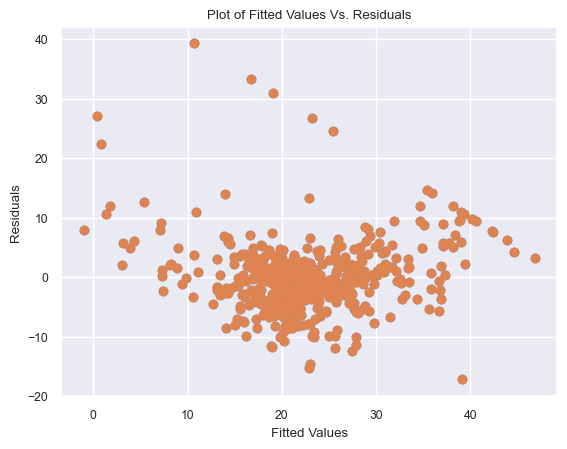

In [172]:
X_sm = sm.add_constant(X)
lm_sm = sm.OLS(bos.PRICE, X_sm).fit()
#Plot for fitted values vs. residuals
_=plt.scatter(lm_sm.fittedvalues, lm_sm.resid)
_=plt.title('Plot of Fitted Values Vs. Residuals')
_=plt.xlabel('Fitted Values')
_=plt.ylabel('Residuals')
_=plt.show()

The scatter plot for fitted values vs. residuals shows a non linear pattern like a U shape and non constant variance or heteroscedasticity. So, it looks like we may have violated the linearity and constant standard deviation assumptions for our model.

<p><b>Exercise:</b> Construct a quantile plot of the residuals. What does the plot tell you?</p>

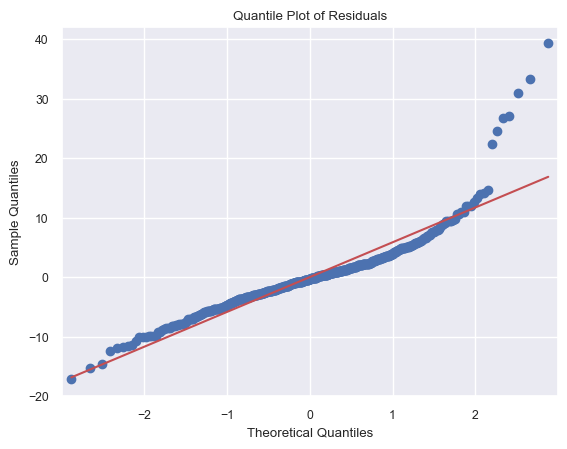

In [177]:
#Quantile Plot of the residuals
_=sm.qqplot(lm_sm.resid, line='s')
_=plt.title("Quantile Plot of Residuals")
_=plt.show()

The residuals start deviating significantly from the straight diagonal line especially at the higher end. This indicates that the residuals are not normally distributed and the model might be incorrectly predicting the prices for the expensive houses.

<p><b>Exercise:</b> What are some advantages and disadvantages of the fitted vs. residual and quantile plot compared to each other?</p>

Fitted vs. residual plots are very useful for detecting non linearity and unequal variance but do not help us see normality of residuals easily.<p>
Quantile plots on the other hand are excellent for checking the normality assumption for residuals and outliers at the tail ends. However, it is difficult to check the linearity and equal variance assumption using quantile plots.

<p><b>Exercise:</b> Identify any outliers (if any) in your model and write a story describing what these outliers might represent.

Outliers in our model are represented by points on our fitted values vs. residuals plot that have extremely high or extremely low values. We do see quite a few high values and some very low values for residuals. High outliers represent house prices that are predicted to have more value by our model than it should have i.e a house with low crime, less number of rooms and smaller pupil to teacher ratio over priced because our predictor variables are not capturing the intended information and low outliers represent houses being over priced by our model despite the fact that they are not good quality homes but may be in a good neighborhood which makes our model think they should have higher value.

<p><b>Exercise:</b> Construct a leverage plot and identify high leverage points in the model. Write a story explaining possible reasons for the high leverage points.</p>

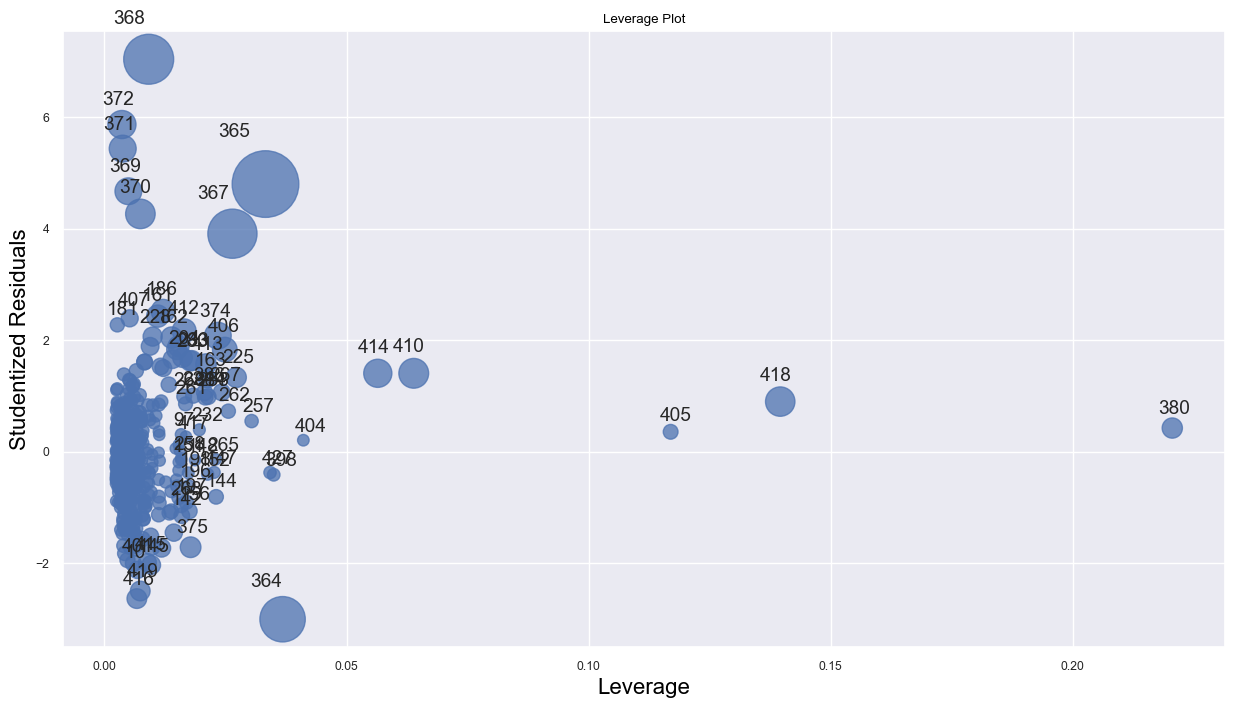

High Leverage/ Outlier Indices:  [145 161 162 163 166 186 195 203 204 225 228 233 283 364 365 366 367 368
 369 370 371 372 374 375 380 406 410 412 413 414 415 416 418 419 453]


In [196]:
#Leverage Plot

fig, ax = plt.subplots(figsize=(15,8))
_=sm.graphics.influence_plot(lm_sm, ax=ax, criterion="cooks")
_=plt.title("Leverage Plot")
plt.show()

#Identifying outliers and high leverage points in an approximate manner
inf = lm_sm.get_influence()
cooks = inf.cooks_distance[0]
n = len(bos.PRICE)
outlier_hl = np.where(cooks > threshold)[0]
print("High Leverage/ Outlier Indices: ",  outlier_hl)

The high leverage points (extreme X values) are possibly due to our model over or under predicting house prices based on extremely small or large values of independent predictor variables (CRIM, RM, PTRATIO).

<p><b>Exercise:</b> Remove the outliers and high leverage points from your model and run the regression again. How do the results change?</p>
</div>

In [199]:
#Removing outliers and rerunning the model
y = bos[['PRICE']]
X = sm.add_constant(X)
x_clean = X.drop(outlier_indices)
y_clean = y.drop(outlier_indices)
lm_sm_clean = sm.OLS(y_clean, x_clean).fit()
lm_sm_clean.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     455.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          2.74e-138
Time:                        09:59:01   Log-Likelihood:                -1310.6
No. Observations:                 471   AIC:                             2629.
Df Residuals:                     467   BIC:                             2646.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.1263      2.985     -3.727      0.000     -16.992      -5.261
CRIM          -0.3141      0.031    -10.259      0.000      -0.374      -0.254
RM             8.1146      0.323     25.092      0.000       7.479       8.750
PTRATIO       -0.9185      0.092     -9.953      0.000      -1.100      -0.737
==============================================================================
Omnibus:                        7.576   Durbin-Watson:                   1.006
Prob(Omnibus):                  0.023   Jarque-Bera (JB):               10.348
Skew:                           0.124   Prob(JB):                      0.00566
Kurtosis:                       3.683   Cond. No.                         329.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Comparing the summary results after removing the ouliers and high leverage points we can see that the model has certainly improved from our previous model based on the following <p>

1. $R^2$ value has improved from .594 to .745.
2. AIC score has gone down from 3232 to 2629
3. Standard errors have gone down for indicating improved estimates for coefficients.